In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Set plot style
plt.style.use('default')
sns.set_theme()

In [2]:
train_data = pd.read_csv('archive/train.csv')
val_data = pd.read_csv('archive/validation.csv')
test_data = pd.read_csv('archive/test.csv')

In [9]:
# exclude_columns = ['TestScore_Math', 'TestScore_Reading', 'TestScore_Science', 'GPA']
exclude_columns = ['GPA']
features = [col for col in train_data.columns if col not in exclude_columns]
target = 'GPA'

In [10]:
train_x = train_data[features].copy()
val_x = val_data[features].copy()
test_x = test_data[features].copy()



le_dict = {}
for feature in train_x.columns:
    if train_x[feature].dtype == 'object':
        le = LabelEncoder()
        le_dict[feature] = le
        train_x[feature] = le.fit_transform(train_x[feature])
        val_x[feature] = le.transform(val_x[feature])
        test_x[feature] = le.transform(test_x[feature])
# Prepare target
y_train = train_data[target]
y_val = val_data[target]
y_test = test_data[target]

In [11]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_x)
X_val_scaled = scaler.transform(val_x)
X_test_scaled = scaler.transform(test_x)

In [12]:
# Initialize and train model
model = Lasso(random_state=42)

# Hyperparameter tuning
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False],
    'max_iter': [10000]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred_train = best_model.predict(X_train_scaled)
y_pred_val = best_model.predict(X_val_scaled)
y_pred_test = best_model.predict(X_test_scaled)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'alpha': 0.001, 'fit_intercept': True, 'max_iter': 10000}


In [13]:
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nPerformance on {dataset_name} dataset:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate on all datasets
evaluate_model(y_train, y_pred_train, "Training")
evaluate_model(y_val, y_pred_val, "Validation")
evaluate_model(y_test, y_pred_test, "Test")


Performance on Training dataset:
MSE: 0.0879
RMSE: 0.2965
R² Score: 0.5838

Performance on Validation dataset:
MSE: 0.0878
RMSE: 0.2964
R² Score: 0.5847

Performance on Test dataset:
MSE: 0.0879
RMSE: 0.2965
R² Score: 0.5835


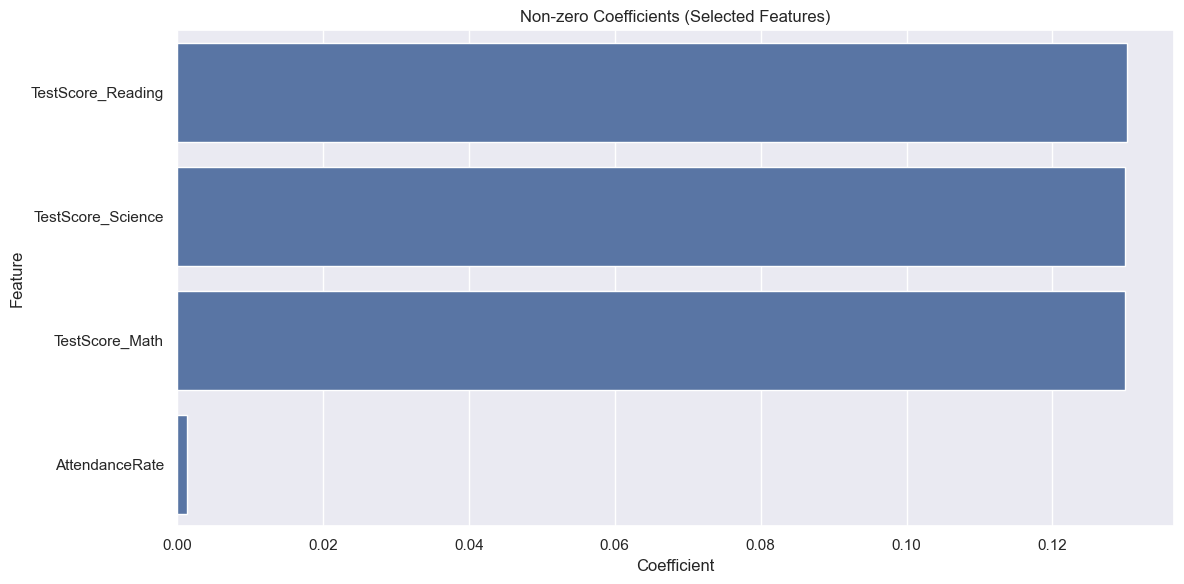


Number of selected features: 4
Number of zero coefficients: 16


In [14]:
# Get coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': best_model.coef_
})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Absolute_Coefficient', ascending=False)

# Plot non-zero coefficients
non_zero_coef = coefficients[coefficients['Coefficient'] != 0]
plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=non_zero_coef)
plt.title('Non-zero Coefficients (Selected Features)')
plt.tight_layout()
plt.show()

# Print number of selected features
print(f"\nNumber of selected features: {len(non_zero_coef)}")
print(f"Number of zero coefficients: {len(coefficients) - len(non_zero_coef)}")

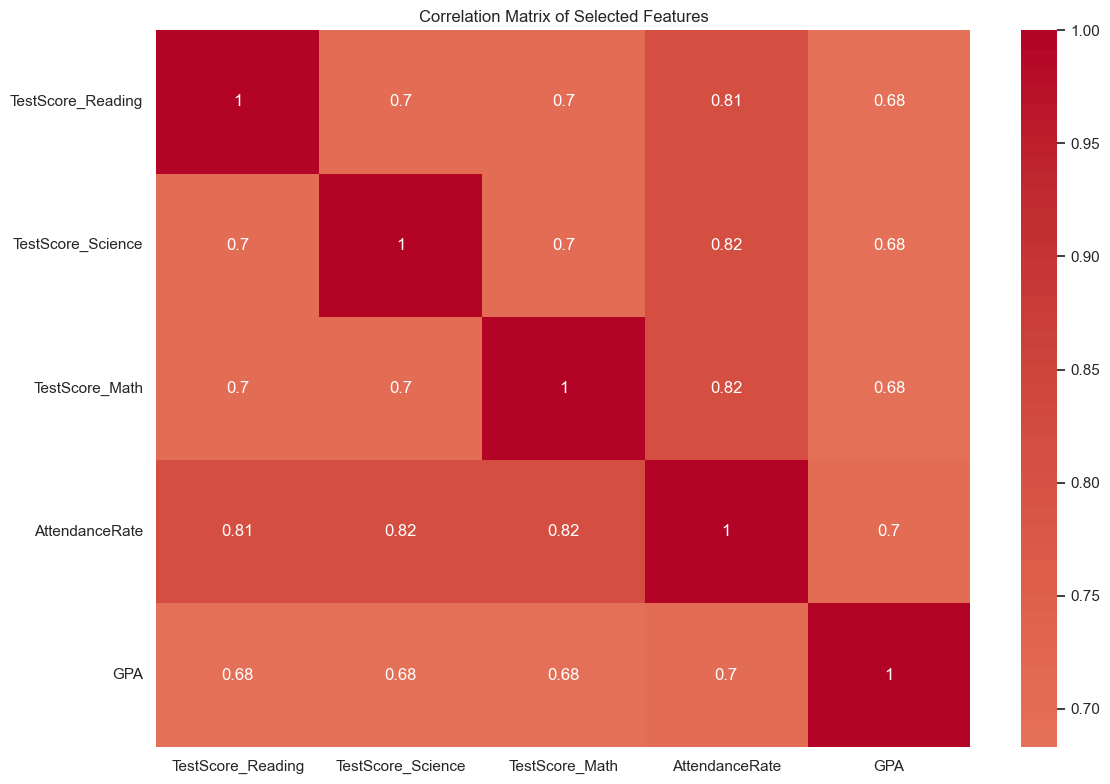


Correlation with GPA for selected features:
GPA                  1.000000
AttendanceRate       0.696722
TestScore_Reading    0.683433
TestScore_Science    0.683300
TestScore_Math       0.683268
Name: GPA, dtype: float64


In [15]:
# Calculate correlation matrix for selected features
selected_features = non_zero_coef['Feature'].tolist()
correlation_matrix = train_data[selected_features + [target]].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Selected Features')
plt.tight_layout()
plt.show()

# Print correlation with target
print("\nCorrelation with GPA for selected features:")
print(correlation_matrix[target].sort_values(ascending=False))

In [16]:
# Save results
results = {
    'model_params': {
        'alpha': best_model.alpha,
        'fit_intercept': best_model.fit_intercept,
        'intercept': best_model.intercept_,
        'selected_features': non_zero_coef['Feature'].tolist(),
        'coefficients': dict(zip(features, best_model.coef_))
    },
    'performance': {
        'train': {
            'mse': mean_squared_error(y_train, y_pred_train),
            'rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'r2': r2_score(y_train, y_pred_train)
        },
        'validation': {
            'mse': mean_squared_error(y_val, y_pred_val),
            'rmse': np.sqrt(mean_squared_error(y_val, y_pred_val)),
            'r2': r2_score(y_val, y_pred_val)
        },
        'test': {
            'mse': mean_squared_error(y_test, y_pred_test),
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
            'r2': r2_score(y_test, y_pred_test)
        }
    }
}

# Save feature importance to CSV
coefficients.to_csv('feature_importance_total.csv', index=False)

# Print final summary
print("\n=== Final Analysis Results ===")
print("\nSelected Features and Their Coefficients:")
print(non_zero_coef)
print("\nModel Intercept:", best_model.intercept_)


=== Final Analysis Results ===

Selected Features and Their Coefficients:
              Feature  Coefficient  Absolute_Coefficient
9   TestScore_Reading     0.130154              0.130154
10  TestScore_Science     0.129942              0.129942
8      TestScore_Math     0.129892              0.129892
11     AttendanceRate     0.001316              0.001316

Model Intercept: 2.9967429022722563
